**GAUSSIN Natacha**
**FOURREAU Mathis**

*ESILV IF3 - Commodities Markets and Models*
 
**Reference:** Palazzi, Rafael Baptista. (2025). *Trading Games: Beating Passive Strategies in the Bullish Crypto Market*. Journal of Futures Markets, Wiley.  
**GitHub (original code):** https://github.com/rafaelpalazzi/trading-games-crypto

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from arch.unitroot import PhillipsPerron
from scipy.stats import kurtosis, skew
from statsmodels.tsa.vector_ar.vecm import coint_johansen
import matplotlib.pyplot as plt
from itertools import product



### Methodology:
1. Obtain the serie of prices of our assets
2. transform the prices (ex: log)
3. Selecting the pairs that interesting us
3. compute rolling mean + rolling standard deviation of the spreads
4. Compute the Z score
5. Generate trading signal
6. execute or no the trade
7. calcul of the performance metrics

In [28]:
df_prices = pd.read_csv("data.csv")

We transform our prices into log prices 

In [30]:
log_prices = np.log(df_prices.iloc[:, 1:])
log_returns = log_prices.diff()

In [31]:
log_prices

,1688.T,ADM,AGRO,BG,CF,DBA,FDP,KRBL.NS,MOS,NTR,VC2.SI,VFF,Futures
0,5.808142,3.641097,2.005318,3.868615,3.676157,2.669161,3.376140,5.502496,2.907961,3.656559,0.238620,1.754404,2.550226
1,5.805135,3.628978,2.010097,3.860235,3.666985,2.671604,3.366462,5.534443,2.915639,3.666239,0.260478,1.742219,2.552565
2,5.805135,3.617832,2.007711,3.848774,3.671582,2.666711,3.375557,5.523782,2.924680,3.665821,0.255058,1.724551,2.552565
3,5.805135,3.607467,2.017223,3.841477,3.666766,2.669161,3.370873,5.551963,2.924206,3.663723,0.260478,1.724551,2.564949
4,5.802118,3.602927,2.017223,3.835744,3.649054,2.678293,3.369111,5.546280,2.901195,3.654866,0.249609,1.686399,2.570320
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1476,6.314815,4.242908,2.232163,4.792562,4.647271,3.257712,3.754595,5.800607,3.306153,4.327306,-0.133531,1.238374,2.362739
1477,6.306275,4.219361,2.211566,4.758921,4.666265,3.258865,3.744314,5.800607,3.279258,4.309725,-0.139262,1.205971,2.359910
1478,6.310827,4.207971,2.260721,4.745019,4.651195,3.262701,3.753262,5.769882,3.250084,4.298509,-0.174353,1.232560,2.345645
1479,6.302619,4.197653,2.272126,4.729156,4.707546,3.273743,3.749504,5.809493,3.260411,4.309322,-0.168419,1.217876,2.378620


### Cointegration tests

First recall the definition of cointegration from the course

Cointegration: Two or more non-stationary series share a common
stochastic trend. A linear combination of them is stationary.

Statistical Interpretation: Deviation from equilibrium are mean-reverting


### Testing for Cointegration: The Johansen Procedure

##### Step 1: Confirm both series are I(1) (unit root tests)

That means that the serie of price is not stationnary but its increment process are. For that purpose we can use Augmented Dickey-Fuller (ADF) or Phillips-Perron (PP) test.

In [32]:
def compute_stats(data):

    results = []

    for col in data.columns:
        
        series = data[col].dropna()

        adf_p = adfuller(series)[1]
        pp_p = PhillipsPerron(series).pvalue
        
        mean = series.mean()
        std = series.std()
        min_v = series.min()
        max_v = series.max()
        kurt = kurtosis(series)
        skewness = skew(series)

        results.append([col,round(adf_p,3),round(pp_p,3),round(mean,3),round(std,3),round(min_v,3),round(max_v,3),round(kurt,3),round(skewness,3)])

    columns = ["Symbol","ADF test","PP test","Mean","Std","Min","Max","Kurtosis","Skewness"]

    return pd.DataFrame(results, columns=columns)

levels_table = compute_stats(log_prices)
returns_table = compute_stats(log_returns)

print("LEVELS")
levels_table

LEVELS


,Symbol,ADF test,PP test,Mean,Std,Min,Max,Kurtosis,Skewness
0,1688.T,0.476,0.483,6.210,0.268,5.591,6.636,-0.354,-0.738
1,ADM,0.399,0.433,4.014,0.258,3.206,4.477,-0.119,-0.553
2,AGRO,0.379,0.374,2.063,0.296,1.150,2.464,1.018,-1.293
3,BG,0.605,0.637,4.316,0.324,3.235,4.816,1.028,-1.343
4,CF,0.766,0.781,4.112,0.427,2.906,4.752,-0.312,-0.976
5,DBA,0.916,0.919,2.932,0.237,2.452,3.310,-0.917,-0.209
6,FDP,0.696,0.592,3.253,0.177,2.884,3.755,-0.399,0.559
7,KRBL.NS,0.093,0.134,5.651,0.254,4.534,6.180,-0.020,-0.433
8,MOS,0.438,0.411,3.346,0.401,1.825,4.256,0.963,-0.837
9,NTR,0.561,0.599,3.959,0.285,3.023,4.624,0.311,-0.530


In [33]:
print("\nLOG RETURNS")
returns_table


LOG RETURNS


,Symbol,ADF test,PP test,Mean,Std,Min,Max,Kurtosis,Skewness
0,1688.T,0.0,0.0,0.000,0.018,-0.136,0.213,19.389,1.270
1,ADM,0.0,0.0,0.000,0.020,-0.277,0.098,29.251,-2.168
2,AGRO,0.0,0.0,0.000,0.028,-0.261,0.126,9.170,-0.945
3,BG,0.0,0.0,0.001,0.021,-0.154,0.122,5.468,-0.663
4,CF,0.0,0.0,0.001,0.026,-0.181,0.151,5.517,-0.591
5,DBA,0.0,0.0,0.000,0.009,-0.050,0.050,2.351,-0.315
6,FDP,0.0,0.0,0.000,0.024,-0.172,0.225,15.292,0.063
7,KRBL.NS,0.0,0.0,0.000,0.030,-0.223,0.162,8.571,-0.333
8,MOS,0.0,0.0,0.000,0.032,-0.322,0.159,11.651,-1.067
9,NTR,0.0,0.0,0.000,0.023,-0.135,0.112,4.021,-0.490


These table, very similar to the one exposed in the main article of this trading game "Trading Games: Beating Passive Strategies in the Bullish
Crypto Market" confirm that any prices are stationnary with high p-values for ADF test and PP test and every log returns are stationnary with p-value < 0.001. We can thus keep all the series of prices that seems to be I(1).

Step 2: Test for cointegration using Johansen test

In [34]:
assets = log_prices.columns
results = []

for i in range(len(assets)):
    
    for j in range(i+1, len(assets)):
        
        a = assets[i]
        b = assets[j]

        

        pair_df = log_prices[[a, b]].dropna()

        if len(pair_df) < 50:
            continue
        joh = coint_johansen(pair_df,det_order=0,k_ar_diff=1)

        trace_stat = joh.lr1[0]
        crit_95 = joh.cvt[0,1]

        cointegrated = trace_stat > crit_95
        results.append({"Asset 1": a,"Asset 2": b,"Trace Stat": trace_stat,"Critical 95%": crit_95,"Cointegrated": cointegrated})

results_df = pd.DataFrame(results)

results_df = results_df.sort_values("Trace Stat", ascending=False)

cointegrated_pairs = results_df[results_df["Cointegrated"] == 1][["Asset 1", "Asset 2"]]

In [35]:
results_df

,Asset 1,Asset 2,Trace Stat,Critical 95%,Cointegrated
23,AGRO,BG,19.502660,15.4943,True
0,1688.T,ADM,19.114028,15.4943,True
7,1688.T,MOS,18.644234,15.4943,True
75,VC2.SI,VFF,15.984779,15.4943,True
62,FDP,Futures,15.888757,15.4943,True
...,...,...,...,...,...
15,ADM,DBA,3.611718,15.4943,False
52,DBA,MOS,3.449377,15.4943,False
53,DBA,NTR,2.958389,15.4943,False
4,1688.T,DBA,2.899856,15.4943,False


### Step 3: If cointegrated, estimate the relationship

For each cointegrated pairs there exist a cointegrated relationship of the following form:

$$
Y_{1,t} = \mu + \gamma Y_{2,t} + \varepsilon_t, \quad \varepsilon_t \sim I(0)
$$

where $\mu$ is the intercept,$\gamma$ is the cointegrating coefficient,and $\varepsilon_t$
is a stationary error term. To estimate we can use VECM estimation like in the course, but this method is less direct to obtain $\mu$ and $\gamma$, in the main paper they employ the Eagle and Granger method which is way more adapted in our situation.

In [36]:
#We keep only the cointegrated pairs

Asset_cointegrated = results_df[results_df["Cointegrated"]== 1][["Asset 1", "Asset 2"]]

#This function aim to estimate the mu and gamma coefficient for a cointegrated pair
def estimate_coint_coeffs(Y):

    Y = Y.dropna().values
    Asset_1 = Y[:, 0]
    Asset_2 = Y[:, 1]

    X = np.column_stack([np.ones(len(Asset_2)), Asset_2])

    beta = np.linalg.lstsq(X, Asset_1, rcond=None)[0]

    mu = beta[0]
    gamma = beta[1]

    return mu, gamma


Afet that we can write the spread $S_t$:

$$
S_t = Y_{1,t} - \gamma Y_{2,t}
$$

and thus this spread is mean reverting and can be used for a trading strategy based on statistical arbitrage


To generate trading signals, we normalize the spread by calculating the Z-score, which measures the spread's deviation from it's rolling mean, scaled by it's rolling standard deviation. The Z-score is defined as:

$$
Z_t = \frac{S_t - \mu_{S_t}}{\sigma_{S_t}}
$$

where $\mu_{S_t}$ is the spread's rolling mean over a lookback period $L$,and $\sigma_{S_t}$ is the rolling standard deviation of the spread over the same period.

In [37]:
# function that calculate the spread (normalized)

def spread(Y, gamma):
    vect_spread = (Y.iloc[:, 0] - gamma*Y.iloc[:, 1])/(1 + np.abs(gamma))
    return vect_spread

# fonction that calculate the Z-score

def Z_score(vect_spread, lookback):
    vect_Z_score = np.zeros(vect_spread.size - lookback)

    for i in range(vect_spread.size - lookback):
        vect_Z_score[i] = (vect_spread[lookback+i] - np.mean(vect_spread[i:i+lookback]))/(np.std(vect_spread[i:i+lookback]))
    return vect_Z_score


### Générer le signal de trading

We have 
$$
s_t =
\begin{cases}
1 & \text{if } Z_t \le \text{Threshold}_{Long} \\
-1 & \text{if } Z_t \ge \text{Threshold}_{Short} \\
0 & \text{otherwise}
\end{cases}
$$

$s_t$ represent the position taken at time t (1 for long, 0 for no position and -1 for short). The thresholds are dynamically ajusted based on rolling volatility.

In [38]:
def generate_signal(vect_Z_score, threshold_long, threshold_short):
    vect_signal = np.zeros(len(vect_Z_score))

    vect_signal[vect_Z_score <= threshold_long] = 1
    vect_signal[vect_Z_score >= threshold_short] = -1

    return vect_signal

### Compute the returns

We first consider the classical return:

$$
R_t = \text{Signal}_{t-1} \cdot \Delta S_t 
$$

where $\text{Signal}_{t-1}$ correspond to the position at $t-1$ (it can of course be no position, in this case the return is 0).

In order to have a more realistic approach, we also consider transaction cost that we applie in case of change of position (change of signal). The return write now:

$$
R_t = \text{Signal}_{t-1} \cdot \Delta S_t - c \cdot |\Delta \text{Signal}_t|
$$



In [39]:
def compute_returns(vect_spread, signal, transaction_cost):

    spread_return = np.diff(vect_spread, prepend=np.nan)

    signal_lag = np.roll(signal, 1)
    signal_lag[0] = 0

    delta_signal = np.diff(signal, prepend=0)

    returns = signal_lag * spread_return - transaction_cost * np.abs(delta_signal)

    return returns

### Reduce de risk: Avoid trading during extreme market conditions

Especially we aim to don't buy or sell when the volatility is to high. For this purpose we first calculate the rolling volatility of spread returns using a specified lookback window $L_v$:

$$
\sigma_t = \sqrt{\frac{1}{L_v} \sum_{i=t-L_v+1}^{t} (r_i - \bar{r})^2}
$$

In [40]:
def rolling_vol(vect_return, L_v):
    vect_vol = np.full(vect_return.size, np.nan)
    
    for t in range(L_v-1, vect_return.size):
        vect_vol[t] = np.std(vect_return[t-L_v+1:t+1])
    return vect_vol

In order to decide whether we can execute order or not we compute the mean volatility (only compute on train data to avoid data leakage)

$$
\bar{\sigma} = \frac{1}{T} \sum_{t=1}^{T} \sigma_t
$$

In [41]:
def sigma_avg(vect_vol):
    return np.nanmean(vect_vol)

we then define the volatility filter as the binary indicator function:

$$
\text{VolFilter}_t =
\begin{cases}
1 & \text{if } \sigma_t \le k \bar{\sigma} \\
0 & \text{if } \sigma_t > k \bar{\sigma}
\end{cases}
$$

In [42]:
def vol_filter(vect_vol, vol_avg, k):
    vect_vol_filter = np.where(np.isnan(vect_vol), False, vect_vol <= k * vol_avg)
    return vect_vol_filter

Then we can apply this filter to our trading signals:
$$
\text{Signal}_t^{\text{filtered}} = \text{Signal}_t \cdot \text{VolFilter}_t
$$

In [43]:
def signal_filtered(vect_signal, vect_vol_filter):
    vect_signal_filtered = vect_signal[-vect_vol_filter.size:]*vect_vol_filter
    return vect_signal_filtered

For this step, two parameters must be chosen: the lookback period $L_v$, which determines how quickly the rolling volatility adapts to market fluctuations, and the parameter $k$, which controls the level of authorized risk. These parameters will be optimized depending on the chosen assets.

## Dynamic trailing stop-loss

This function manages positions using two exit rules:

##### Entry
A position is opened when a signal appears:
- \( +1 \): long spread  
- \( -1 \): short spread  

---

##### Exit 1: Z-score

- Long: exit when $Z_t \geq -\text{exit\_band}$  
- Short: exit when $Z_t \leq \text{exit\_band}$

If `exit_band = 0`: exit at mean reversion  
If `exit_band > 0`: exit earlier (more conservative)

---

##### Exit 2: Trailing Stop (risk control)

A dynamic stop adapts to volatility:

- Long: exit if spread drops from its max  
- Short: exit if spread rises from its min  

$$
\lambda_t = \text{base\_stop} \cdot \max\left(\frac{\sigma_t}{\bar{\sigma}}, 1\right)
$$

---

### Summary

- Entry: extreme Z-score  
- Exit: return toward equilibrium  
- Safety: volatility-adjusted trailing stop  

Hybrid strategy: **mean-reversion + risk management**

In [44]:
def apply_trailing_stop(vect_spread, vect_signal, vect_vol, vol_avg, vect_Z,
                        base_stop=0.01, exit_band=0.0):

    n = len(vect_spread)

    signal_final = np.zeros(n)
    position = 0
    highest = None
    lowest = None

    for t in range(n):

        # volatilité
        if np.isnan(vect_vol[t]) or vol_avg == 0:
            lambda_t = base_stop
        else:
            lambda_t = base_stop * max(vect_vol[t] / vol_avg, 1)

        sig = vect_signal[t]

        # ENTRY
        if position == 0 and sig != 0:
            position = sig
            highest = vect_spread[t]
            lowest = vect_spread[t]

        # EXIT by Z-score band
        if position == 1 and vect_Z[t] >= -exit_band:
            position = 0
            highest = None
            lowest = None

        elif position == -1 and vect_Z[t] <= exit_band:
            position = 0
            highest = None
            lowest = None

        # TRAILING STOP
        elif position == 1:
            highest = max(highest, vect_spread[t])
            stop_level = highest - lambda_t * abs(highest)

            if vect_spread[t] < stop_level:
                position = 0
                highest = None
                lowest = None

        elif position == -1:
            lowest = min(lowest, vect_spread[t])
            stop_level = lowest + lambda_t * abs(lowest)

            if vect_spread[t] > stop_level:
                position = 0
                highest = None
                lowest = None

        signal_final[t] = position

    return signal_final

### Pipeline

In this part we implement all the presented features in an unique pipeline. 

In [45]:
def run_strategy(Y, lookback, L_v, k, threshold, transaction_cost, split=0.6, base_stop = 0.01,exit_band = 0.0):

    n = len(Y)
    split_idx = int(split * n)

    Y_train = Y.iloc[:split_idx]
    Y_test = Y.iloc[split_idx:]

    # cointegration coefficients (TRAIN)
    mu, gamma = estimate_coint_coeffs(Y_train)

    # spread 
    vect_spread = spread(Y, gamma).values

    # z-score
    vect_Z = Z_score(vect_spread, lookback)

    vect_signal = generate_signal(vect_Z, -threshold, threshold)

    vect_spread = vect_spread[lookback:]

    # align Z and signals
    vect_signal = vect_signal

    # compute spread returns
    spread_returns = np.diff(vect_spread, prepend=np.nan)

    # rolling volatility
    vect_vol = rolling_vol(spread_returns, L_v)

    # compute avg volatility ONLY on train
    vol_avg = np.nanmean(vect_vol[:split_idx])

    # volatility filter
    vect_vol_filter = vol_filter(vect_vol, vol_avg, k)

    vect_signal_filtered = vect_signal * vect_vol_filter

    # trailing stop
    vect_signal_final = apply_trailing_stop(
    vect_spread,
    vect_signal_filtered,
    vect_vol,
    vol_avg,
    vect_Z,
    base_stop,
    exit_band
)

    # returns
    vect_returns = compute_returns(vect_spread, vect_signal_final, transaction_cost)

    #isolate test returns
    test_start = split_idx - lookback

    vect_returns_test = vect_returns[test_start:]

    return {
        "spread": vect_spread,
        "z_score": vect_Z,
        "signal_final": vect_signal_final,
        "returns": vect_returns,
        "volatility": vect_vol,
        "split_index": split_idx
    }

In [46]:
pairs_Y = {}

for asset1, asset2 in cointegrated_pairs[["Asset 1","Asset 2"]].values:

    Y = log_prices[[asset1, asset2]].dropna()

    pairs_Y[(asset1, asset2)] = Y

In [47]:
for pair, Y in pairs_Y.items():

    res = run_strategy(
        Y,
        lookback=30,
        L_v=20,
        k=1.5,
        threshold=0.8,
        transaction_cost=0.00,
    )

    returns = res["returns"]
    split_idx = res["split_index"]

    # cumulative returns
    cum_returns = np.nancumsum(returns)

In [48]:
split_plot_idx = split_idx - 50  # lookback = 50
time_index = Y.index[-len(cum_returns):]

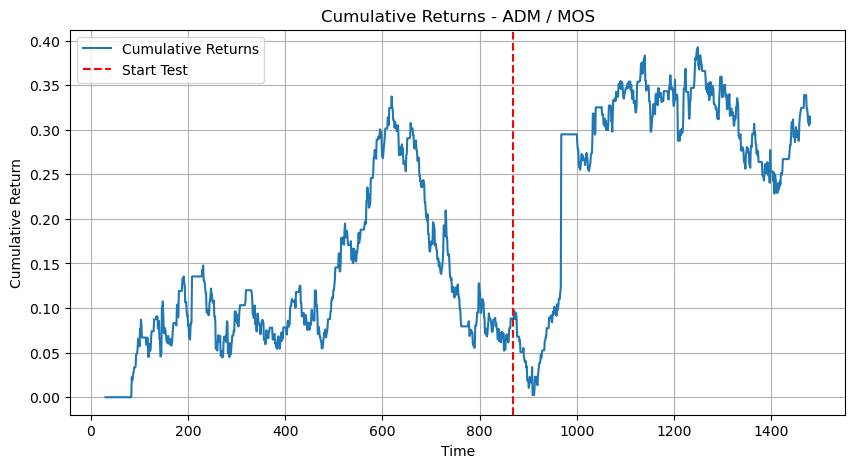

In [49]:

plt.figure(figsize=(10, 5))
plt.plot(time_index, cum_returns, label="Cumulative Returns")

# ligne verticale début test
plt.axvline(
    x=time_index[split_plot_idx],
    color='red',
    linestyle='--',
    label='Start Test'
)

plt.title(f"Cumulative Returns - {pair[0]} / {pair[1]}")
plt.xlabel("Time")
plt.ylabel("Cumulative Return")
plt.legend()
plt.grid()

plt.show()

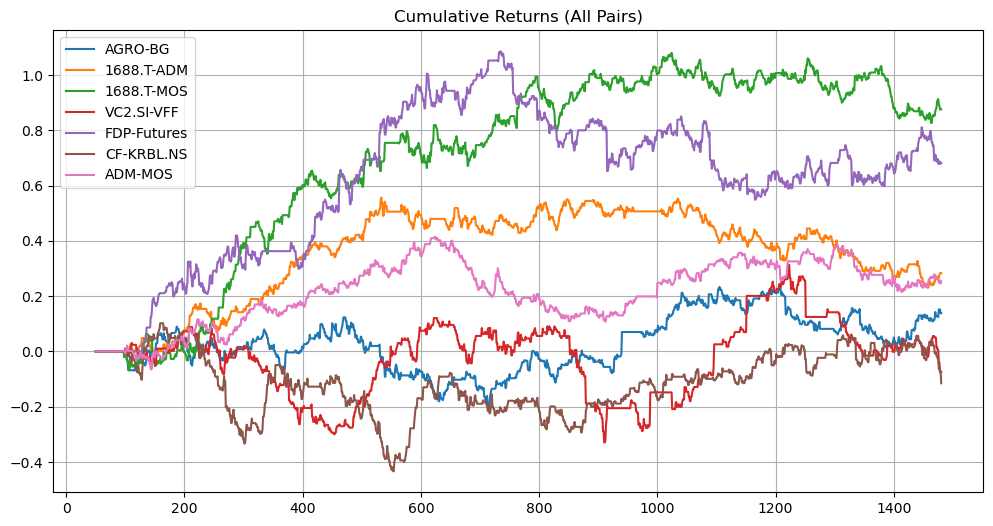

In [50]:
plt.figure(figsize=(12,6))

for pair, Y in pairs_Y.items():

    res = run_strategy(Y, 50, 30, 1.5, 0.7, 0.0)

    returns = res["returns"]
    cum_returns = np.nancumsum(returns)
    time_index = Y.index[-len(cum_returns):]

    plt.plot(time_index, cum_returns, label=f"{pair[0]}-{pair[1]}")

plt.legend()
plt.title("Cumulative Returns (All Pairs)")
plt.grid()
plt.show()

In [51]:
def plot_zscore_signals(df, threshold=0.7):

    z = df["z_score"]
    signal = df["signal_final"]

    long_points = z[signal == 1]
    short_points = z[signal == -1]

    plt.figure(figsize=(12,5))

    # Z-score
    plt.plot(z, color="black", linewidth=1)

    # Thresholds
    plt.axhline(threshold, linestyle="--", color="red", alpha=0.6)
    plt.axhline(-threshold, linestyle="--", color="red", alpha=0.6)

    # Long signals
    plt.scatter(long_points.index, long_points,
                color="green", label="Long", s=30)

    # Short signals
    plt.scatter(short_points.index, short_points,
                color="red", label="Short", s=30)

    plt.ylabel("Z-score")
    plt.xlabel("Index")
    plt.title("Z-score Trading Signals")
    plt.legend()

    plt.show()

In [52]:
def evaluate_strategy_train(Y, params):

    res = run_strategy(
        Y,
        lookback=params["lookback"],
        L_v=params["L_v"],
        k=params["k"],
        threshold=params["threshold"],
        transaction_cost=0.0,
        split=0.6,
        base_stop=params["base_stop"],
        exit_band=params["exit_band"]
    )

    returns = res["returns"]
    split_idx = res["split_index"]

    train_returns = returns[:split_idx]

    if np.nanstd(train_returns) == 0:
        return -np.inf

    sharpe = np.nanmean(train_returns) / np.nanstd(train_returns) * np.sqrt(252)

    return sharpe

In [53]:
param_grid = {
    "lookback": [30, 50, 70],
    "L_v": [20, 30, 50],
    "k": [1.2],
    "threshold": [0.5, 0.7],
    "base_stop": [0.01],
    "exit_band": [0.0, 0.1]
}

In [54]:
def optimize_parameters(Y, param_grid):

    keys = param_grid.keys()
    combinations = list(product(*param_grid.values()))

    best_score = -np.inf
    best_params = None
    results = []

    for values in combinations:

        params = dict(zip(keys, values))

        score = evaluate_strategy_train(Y, params)

        results.append({**params, "Sharpe": score})

        if score > best_score:
            best_score = score
            best_params = params

    results_df = pd.DataFrame(results).sort_values("Sharpe", ascending=False)

    return best_params, results_df

In [55]:
best_params_all = {}

for pair, Y in pairs_Y.items():

    print(f"Optimizing {pair}...")

    best_params, results_df = optimize_parameters(Y, param_grid)

    best_params_all[pair] = best_params

    print("Best params:", best_params)
    print("Best Sharpe:", results_df.iloc[0]["Sharpe"])

Optimizing ('AGRO', 'BG')...
Best params: {'lookback': 70, 'L_v': 20, 'k': 1.2, 'threshold': 0.5, 'base_stop': 0.01, 'exit_band': 0.0}
Best Sharpe: 0.5774815152393215
Optimizing ('1688.T', 'ADM')...
Best params: {'lookback': 70, 'L_v': 50, 'k': 1.2, 'threshold': 0.5, 'base_stop': 0.01, 'exit_band': 0.0}
Best Sharpe: 1.6754454423925678
Optimizing ('1688.T', 'MOS')...
Best params: {'lookback': 50, 'L_v': 50, 'k': 1.2, 'threshold': 0.7, 'base_stop': 0.01, 'exit_band': 0.1}
Best Sharpe: 1.5148511676418137
Optimizing ('VC2.SI', 'VFF')...
Best params: {'lookback': 30, 'L_v': 30, 'k': 1.2, 'threshold': 0.5, 'base_stop': 0.01, 'exit_band': 0.0}
Best Sharpe: 0.019369405578053844
Optimizing ('FDP', 'Futures')...
Best params: {'lookback': 50, 'L_v': 20, 'k': 1.2, 'threshold': 0.7, 'base_stop': 0.01, 'exit_band': 0.1}
Best Sharpe: 1.0345928004966571
Optimizing ('CF', 'KRBL.NS')...
Best params: {'lookback': 70, 'L_v': 30, 'k': 1.2, 'threshold': 0.7, 'base_stop': 0.01, 'exit_band': 0.1}
Best Sharpe:

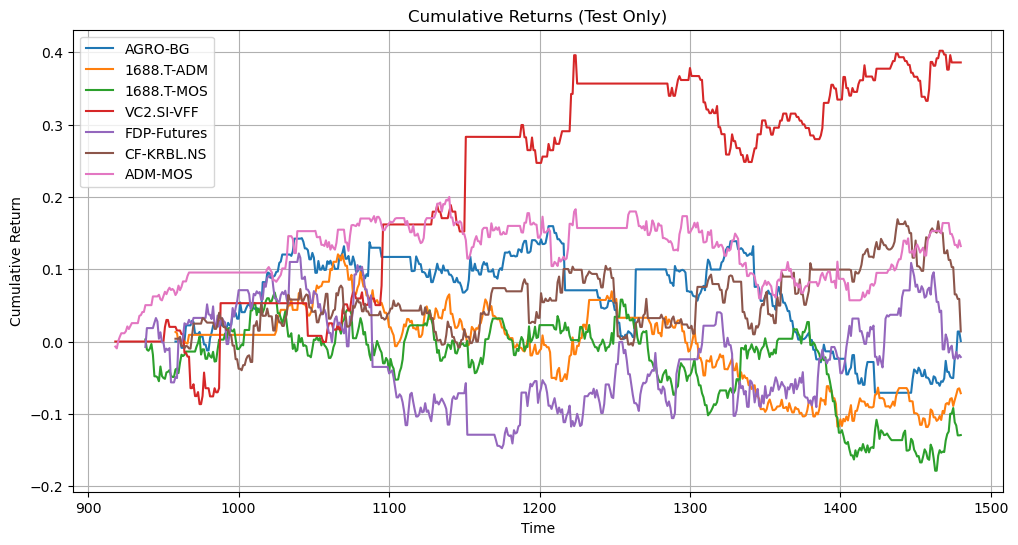

In [56]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(12,6))

for pair, Y in pairs_Y.items():

    params = best_params_all[pair]

    res = run_strategy(
        Y,
        lookback=params["lookback"],
        L_v=params["L_v"],
        k=params["k"],
        threshold=params["threshold"],
        transaction_cost=0.0,
        split=0.6,
        base_stop=params["base_stop"],
        exit_band=params["exit_band"]
    )

    returns = res["returns"]
    split_idx = res["split_index"]

    # TEST ONLY
    test_returns = returns[split_idx:]

    # cumulative returns
    cum_returns = np.nancumsum(test_returns)

    # align time index
    time_index = Y.index[-len(cum_returns):]

    plt.plot(time_index, cum_returns, label=f"{pair[0]}-{pair[1]}")

plt.title("Cumulative Returns (Test Only)")
plt.xlabel("Time")
plt.ylabel("Cumulative Return")
plt.legend()
plt.grid()

plt.show()

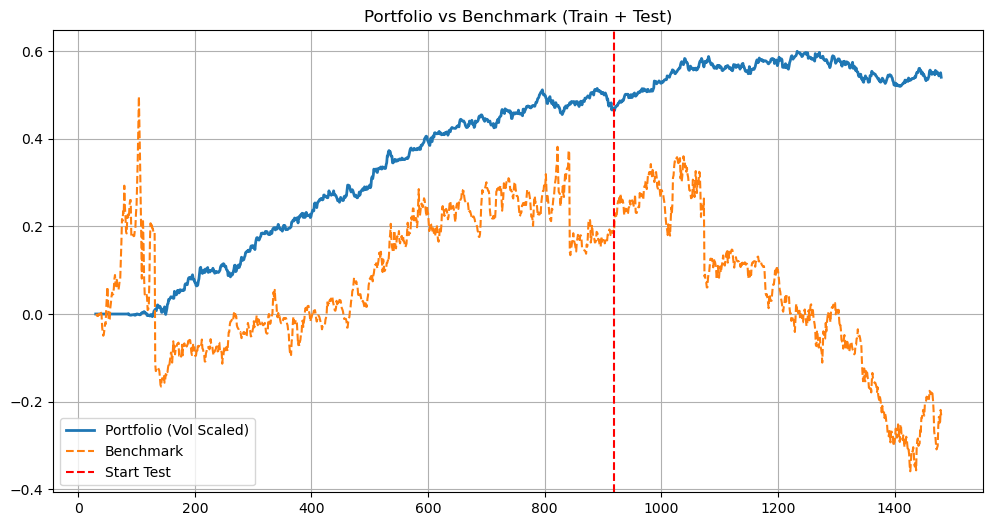

In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

returns_dict = {}
split_index_ref = None

# =========================
# 1. Collect returns
# =========================

for pair, Y in pairs_Y.items():

    params = best_params_all[pair]

    res = run_strategy(
        Y,
        lookback=params["lookback"],
        L_v=params["L_v"],
        k=params["k"],
        threshold=params["threshold"],
        transaction_cost=0.0,
        split=0.6,
        base_stop=params["base_stop"],
        exit_band=params["exit_band"]
    )

    returns = res["returns"]
    split_idx = res["split_index"]

    time_index = Y.index[-len(returns):]

    returns_dict[f"{pair[0]}-{pair[1]}"] = pd.Series(returns, index=time_index)

    if split_index_ref is None:
        split_index_ref = split_idx

# =========================
# 2. Align all returns
# =========================

df_returns = pd.DataFrame(returns_dict)

# =========================
# 3. Volatility scaling (TRAIN ONLY)
# =========================

train_returns = df_returns.iloc[:split_index_ref]

vols = train_returns.std()

weights = 1 / vols
weights = weights / weights.sum()

# =========================
# 4. Portfolio returns
# =========================

portfolio_returns = df_returns.mul(weights, axis=1).sum(axis=1)

portfolio_cum = portfolio_returns.cumsum()

# =========================
# 5. Benchmark
# =========================

benchmark_price = log_prices["Futures"].iloc[-len(portfolio_cum):]
benchmark_price.index = portfolio_cum.index

benchmark_returns = benchmark_price.diff()
benchmark_cum = benchmark_returns.cumsum()

# =========================
# 6. Plot
# =========================

plt.figure(figsize=(12,6))

plt.plot(portfolio_cum.index, portfolio_cum, label="Portfolio (Vol Scaled)", linewidth=2)
plt.plot(benchmark_cum.index, benchmark_cum, label="Benchmark", linestyle='--')

# ligne train/test
plt.axvline(
    x=portfolio_cum.index[split_index_ref],
    color='red',
    linestyle='--',
    label='Start Test'
)

plt.title("Portfolio vs Benchmark (Train + Test)")
plt.legend()
plt.grid()

plt.show()

In [58]:
def sharpe_ratio(returns, rf=0.0, freq=252):
    excess_returns = returns - rf / freq
    if np.nanstd(excess_returns) == 0:
        return np.nan
    return np.nanmean(excess_returns) / np.nanstd(excess_returns) * np.sqrt(freq)


def max_drawdown(cum_returns):
    cum_max = np.maximum.accumulate(cum_returns)
    drawdown = cum_returns - cum_max
    return np.min(drawdown)


def calmar_ratio(returns, rf=0.0, freq=252):
    cum_returns = np.nancumsum(returns)
    mdd = abs(max_drawdown(cum_returns))
    if mdd == 0:
        return np.nan
    annual_return = np.nanmean(returns) * freq
    return annual_return / mdd


def annual_return(returns, freq=252):
    return np.nanmean(returns) * freq


def annual_volatility(returns, freq=252):
    return np.nanstd(returns) * np.sqrt(freq)

In [59]:
rf_rate = 0.02  # 2% annuel

results = []

for pair, Y in pairs_Y.items():

    params = best_params_all[pair]

    res = run_strategy(
        Y,
        lookback=params["lookback"],
        L_v=params["L_v"],
        k=params["k"],
        threshold=params["threshold"],
        transaction_cost=0.0,
        split=0.6,
        base_stop=params["base_stop"],
        exit_band=params["exit_band"]
    )

    returns = res["returns"]
    split_idx = res["split_index"]

    # TEST ONLY
    test_returns = returns[split_idx:]

    # metrics
    sharpe = sharpe_ratio(test_returns, rf=rf_rate)
    calmar = calmar_ratio(test_returns, rf=rf_rate)
    ann_ret = annual_return(test_returns)
    ann_vol = annual_volatility(test_returns)

    cum_returns = np.nancumsum(test_returns)
    mdd = max_drawdown(cum_returns)

    results.append({
        "Pair": f"{pair[0]}-{pair[1]}",
        "Sharpe": sharpe,
        "Calmar": calmar,
        "Annual Return": ann_ret,
        "Annual Vol": ann_vol,
        "Max Drawdown": mdd
    })

df_performance = pd.DataFrame(results).sort_values("Sharpe", ascending=False)
df_performance.round(3)

,Pair,Sharpe,Calmar,Annual Return,Annual Vol,Max Drawdown
3,VC2.SI-VFF,0.832,1.170,0.173,0.184,-0.148
6,ADM-MOS,0.312,0.413,0.059,0.125,-0.143
5,CF-KRBL.NS,-0.077,0.043,0.007,0.171,-0.155
0,AGRO-BG,-0.127,0.001,0.000,0.155,-0.230
4,FDP-Futures,-0.133,-0.037,-0.010,0.225,-0.269
1,1688.T-ADM,-0.425,-0.144,-0.034,0.128,-0.239
2,1688.T-MOS,-0.514,-0.244,-0.060,0.156,-0.246


# A Faire

- faire une fonction d'optimization sur les differents parametres validation test
- Afficher sharp ratio, calmar, return
- rédiger mieux la partie dynamic trailing stop 